In [2]:
%pip install pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: C:\Users\Clement\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

# Lire toutes les données du fichier CSV
df = pd.read_csv(r'C:\Users\Clement\OneDrive\Bureau\L3 info\Projet info\dataVilleAnnee\dvf_avec_code_postal.csv', sep=',')

# Nettoyer les noms de colonnes (supprimer les espaces en début et fin)
df.columns = df.columns.str.strip()

# Créer une liste des totaux de mutations pour chaque année de 2014 à 2024
mutations_par_annee = []
for annee in range(2014, 2025):
    total = df[df['Annee'] == annee]['Nb_mutations'].sum()
    mutations_par_annee.append(total)
    print(f"{annee}: {total} mutations")

print(f"\nListe complète : {mutations_par_annee}")

2014: 589477 mutations
2015: 672640 mutations
2016: 722335 mutations
2017: 424835 mutations
2018: 443447 mutations
2019: 912692 mutations
2020: 891738 mutations
2021: 1038553 mutations
2022: 990401 mutations
2023: 765864 mutations
2024: 704182 mutations

Liste complète : [np.int64(589477), np.int64(672640), np.int64(722335), np.int64(424835), np.int64(443447), np.int64(912692), np.int64(891738), np.int64(1038553), np.int64(990401), np.int64(765864), np.int64(704182)]


C:\Users\Clement\AppData\Local\Temp\ipykernel_20540\1696470910.py:4: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\Clement\OneDrive\Bureau\L3 info\Projet info\dataVilleAnnee\dvf_avec_code_postal.csv', sep=',')


In [ ]:
# Diagnostic : Afficher les premières lignes et les noms de colonnes
print("=== COLONNES DISPONIBLES ===")
print(df.columns.tolist())
print(f"\nNombre de colonnes : {len(df.columns)}")
print("\n=== APERÇU DES DONNÉES ===")
print(df.head())
print("\n=== INFO SUR LE DATAFRAME ===")
print(df.info())

In [9]:
# Isoler les colonnes souhaitées depuis le DataFrame df
colonnes_isolees = df[['Annee', 'Prixm2Moyen', 'SurfaceMoy', 'Nb_mutations']]
print(colonnes_isolees)

# ATTENTION : Sauvegarde dans un NOUVEAU fichier pour ne pas écraser l'original
colonnes_isolees.to_csv(r'C:\Users\Clement\OneDrive\Bureau\L3 info\Projet info\dataVilleAnnee\colonnes_isolees.csv', sep=',', index=False)

        Annee  Prixm2Moyen  SurfaceMoy  Nb_mutations
0        2014     1708.900  107.400000            10
1        2014     1338.000   80.333333             3
2        2014     1946.432   85.872000           125
3        2014     2412.200  110.533333            15
4        2014      857.000   70.000000             1
...       ...          ...         ...           ...
320591   2024     2874.000   83.000000             8
320592   2024     3336.000   79.000000            10
320593   2024     2535.000   69.000000           132
320594   2024     2905.000  108.000000             1
320595   2024     2529.000  124.000000             5

[320596 rows x 4 columns]


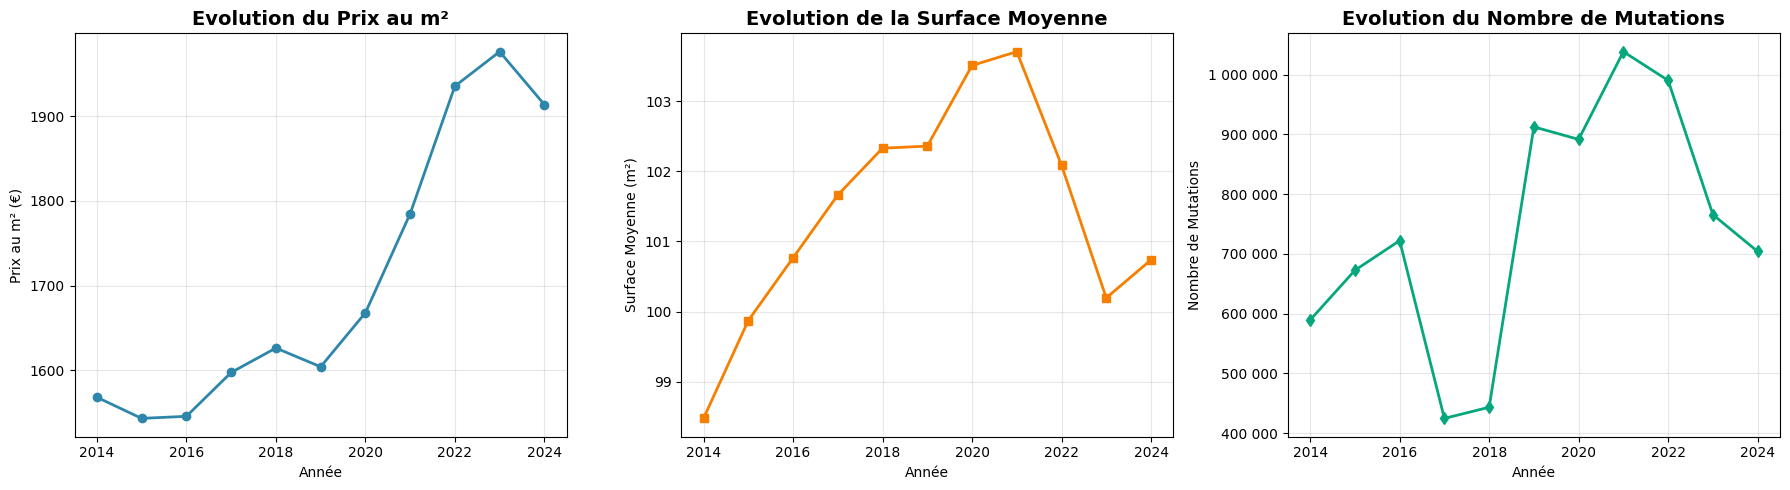


=== ÉVOLUTION PAR ANNÉE ===
    Annee  Prixm2Moyen  SurfaceMoy  Nb_mutations
0    2014  1568.370287   98.478075        589477
1    2015  1543.470744   99.872292        672640
2    2016  1545.907639  100.766303        722335
3    2017  1597.583022  101.661999        424835
4    2018  1626.428492  102.329903        443447
5    2019  1604.320069  102.359006        912692
6    2020  1667.984589  103.508640        891738
7    2021  1784.767483  103.705583       1038553
8    2022  1935.255131  102.088151        990401
9    2023  1975.922665  100.195354        765864
10   2024  1913.486776  100.737622        704182

=== RÉSUMÉ ===
Année avec le plus de mutations : 2021 (1,038,553 mutations)
Année avec le moins de mutations : 2017 (424,835 mutations)


In [12]:
import matplotlib.pyplot as plt

# Grouper les données par année pour obtenir les moyennes et la somme des mutations
donnees_par_annee = df.groupby('Annee').agg({
    'Prixm2Moyen': 'mean',
    'SurfaceMoy': 'mean',
    'Nb_mutations': 'sum'  # Somme totale des transactions par an
}).reset_index()

# Créer une figure avec 3 graphiques côte à côte
plt.figure(figsize=(18, 5))

# Graphique 1 : Evolution du prix au m²
plt.subplot(1, 3, 1)
plt.plot(donnees_par_annee['Annee'], donnees_par_annee['Prixm2Moyen'], marker='o', color='#2E86AB', linewidth=2)
plt.title('Evolution du Prix au m²', fontsize=14, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Prix au m² (€)')
plt.grid(True, alpha=0.3)

# Graphique 2 : Evolution de la surface moyenne
plt.subplot(1, 3, 2)
plt.plot(donnees_par_annee['Annee'], donnees_par_annee['SurfaceMoy'], marker='s', color='#F77F00', linewidth=2)
plt.title('Evolution de la Surface Moyenne', fontsize=14, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Surface Moyenne (m²)')
plt.grid(True, alpha=0.3)

# Graphique 3 : Evolution du nombre de mutations
plt.subplot(1, 3, 3)
plt.plot(donnees_par_annee['Annee'], donnees_par_annee['Nb_mutations'], marker='d', color='#06A77D', linewidth=2)
plt.title('Evolution du Nombre de Mutations', fontsize=14, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Nombre de Mutations')
plt.grid(True, alpha=0.3)
# Formater l'axe Y pour afficher les grands nombres lisiblement
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', ' ')))

plt.tight_layout()
plt.show()

# Afficher les statistiques
print("\n=== ÉVOLUTION PAR ANNÉE ===")
print(donnees_par_annee)
print(f"\n=== RÉSUMÉ ===")
print(f"Année avec le plus de mutations : {donnees_par_annee.loc[donnees_par_annee['Nb_mutations'].idxmax(), 'Annee']} ({donnees_par_annee['Nb_mutations'].max():,.0f} mutations)")
print(f"Année avec le moins de mutations : {donnees_par_annee.loc[donnees_par_annee['Nb_mutations'].idxmin(), 'Annee']} ({donnees_par_annee['Nb_mutations'].min():,.0f} mutations)")

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Lire toutes les données du fichier CSV
df = pd.read_csv(r'C:\Users\Clement\OneDrive\Bureau\L3 info\Projet info\dataVilleAnnee\dvf_consolidated_dataset.csv', sep=',')

# Extraire le code département (2 premiers chiffres du code INSEE)
df['Departement'] = df['INSEE_COM'].str[:2]

# Calculer les moyennes par département et par année
moyennes_dept = df.groupby(['Departement', 'Annee']).agg({
    'Prixm2Moyen': 'mean',
    'SurfaceMoy': 'mean',
    'Nb_mutations': 'sum'
}).reset_index()

# Renommer les colonnes pour plus de clarté
moyennes_dept.columns = ['Departement', 'Annee', 'PrixM2Moyen_Dept', 'SurfaceMoy_Dept', 'Total_Mutations']

# Afficher un aperçu des résultats
print("Moyennes par département :")
print(moyennes_dept.head(20))
print(f"\nNombre de départements : {moyennes_dept['Departement'].nunique()}")
print(f"Années couvertes : {moyennes_dept['Annee'].min()} à {moyennes_dept['Annee'].max()}")

# Statistiques par département (toutes années confondues)
stats_dept = df.groupby('Departement').agg({
    'Prixm2Moyen': 'mean',
    'SurfaceMoy': 'mean',
    'Nb_mutations': 'sum'
}).reset_index()

stats_dept.columns = ['Departement', 'PrixM2Moyen_Global', 'SurfaceMoy_Global', 'Total_Mutations_Global']
stats_dept = stats_dept.sort_values('PrixM2Moyen_Global', ascending=False)

print("\n10 départements les plus chers (prix au m² moyen) :")
print(stats_dept.head(10))

print("\n10 départements les moins chers (prix au m² moyen) :")
print(stats_dept.tail(10))

# Sauvegarder les résultats
moyennes_dept.to_csv(r'C:\Users\Clement\OneDrive\Bureau\L3 info\Projet info\dataVilleAnnee\moyennes_par_departement.csv', sep=',', index=False)
stats_dept.to_csv(r'C:\Users\Clement\OneDrive\Bureau\L3 info\Projet info\dataVilleAnnee\stats_departements_global.csv', sep=',', index=False)

print("\nFichiers sauvegardés !")

Moyennes par département :
   Departement  Annee  PrixM2Moyen_Dept  SurfaceMoy_Dept  Total_Mutations
0           01   2014       1866.198531       101.761833             5198
1           01   2015       1856.039765       103.380409             6036
2           01   2016       1818.266019       104.203961             6595
3           01   2017       1886.474293       105.327996             3910
4           01   2018       1958.707032       104.773026             4111
5           01   2019       1976.358095       105.319136             8529
6           01   2020       2073.985219       105.945840             8343
7           01   2021       2231.059531       107.506609             9885
8           01   2022       2450.152247       105.188709             9240
9           01   2023       2467.543178       103.780598             6951
10          01   2024       2438.744063       105.546174             6579
11          02   2014       1209.201240        99.580423             4145
12         

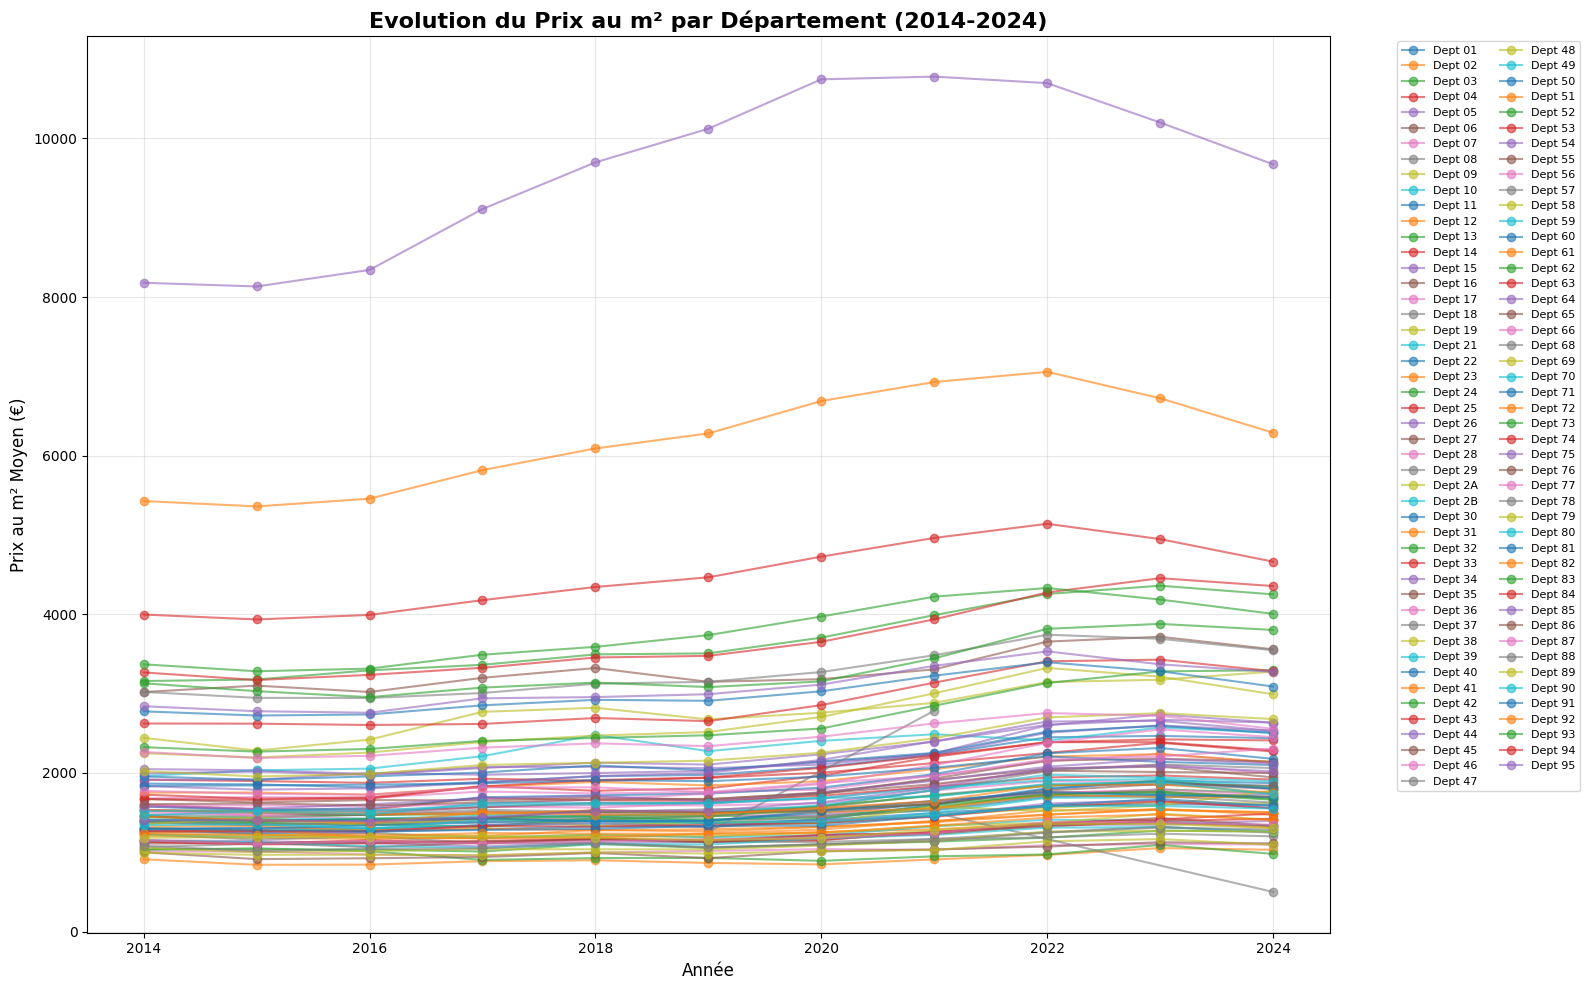

Graphique créé et sauvegardé !


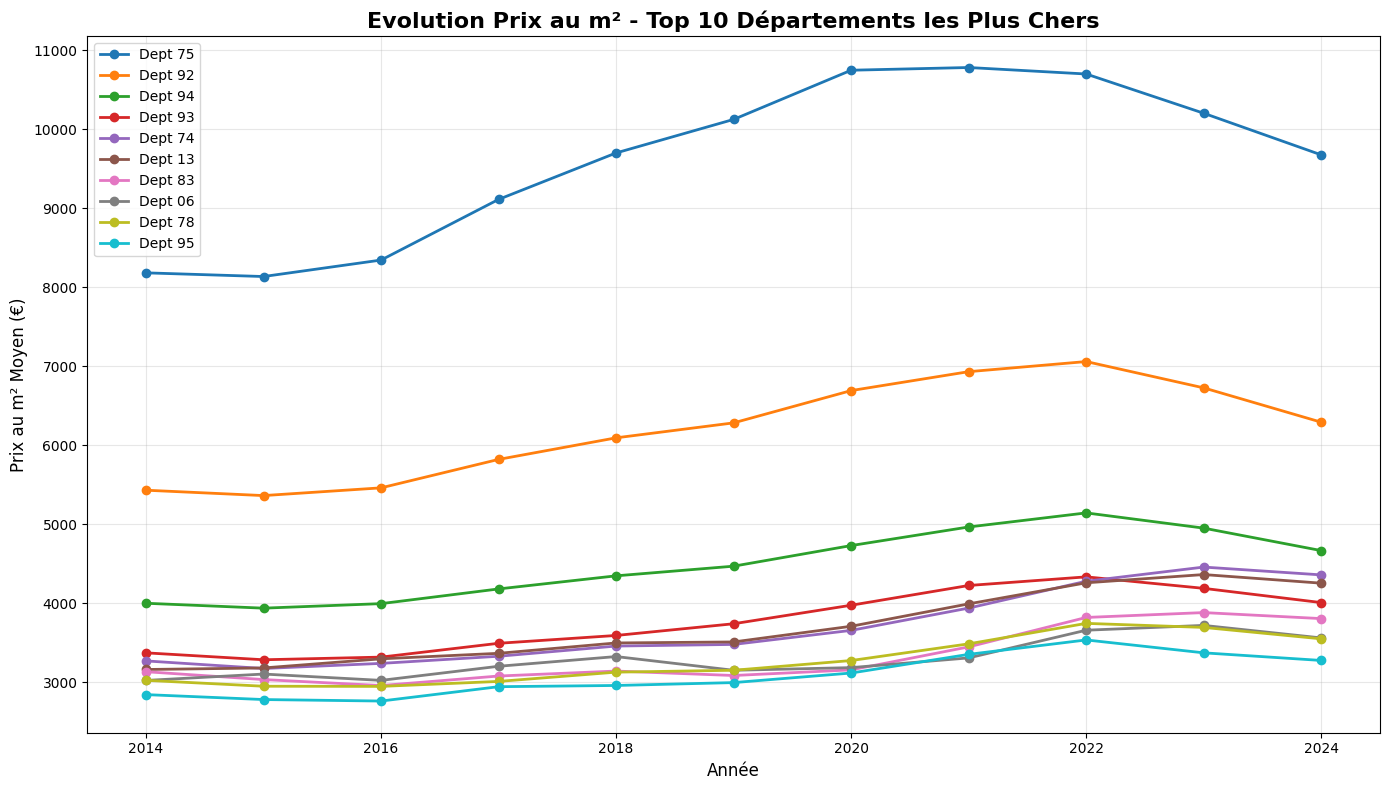

Graphique Top 10 créé et sauvegardé !


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Lire les données (ou utiliser moyennes_dept si déjà calculé)
df = pd.read_csv(r'C:\Users\Clement\OneDrive\Bureau\L3 info\Projet info\dataVilleAnnee\dvf_consolidated_dataset.csv', sep=',')
df['Departement'] = df['INSEE_COM'].str[:2]

# Calculer les moyennes par département et année
moyennes_dept = df.groupby(['Departement', 'Annee']).agg({
    'Prixm2Moyen': 'mean'
}).reset_index()

# Créer un graphique avec toutes les courbes
plt.figure(figsize=(16, 10))

# Tracer une ligne pour chaque département
for dept in moyennes_dept['Departement'].unique():
    data_dept = moyennes_dept[moyennes_dept['Departement'] == dept]
    plt.plot(data_dept['Annee'], data_dept['Prixm2Moyen'], 
             marker='o', linewidth=1.5, alpha=0.6, label=f'Dept {dept}')

plt.title('Evolution du Prix au m² par Département (2014-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Année', fontsize=12)
plt.ylabel('Prix au m² Moyen (€)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(r'C:\Users\Clement\OneDrive\Bureau\L3 info\Projet info\dataVilleAnnee\evolution_prix_departements.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graphique créé et sauvegardé !")

# Version alternative : Top 10 départements les plus chers
plt.figure(figsize=(14, 8))

# Identifier les 10 départements les plus chers (moyenne sur toutes les années)
top_depts = moyennes_dept.groupby('Departement')['Prixm2Moyen'].mean().nlargest(10).index

for dept in top_depts:
    data_dept = moyennes_dept[moyennes_dept['Departement'] == dept]
    plt.plot(data_dept['Annee'], data_dept['Prixm2Moyen'], 
             marker='o', linewidth=2, label=f'Dept {dept}')

plt.title('Evolution Prix au m² - Top 10 Départements les Plus Chers', fontsize=16, fontweight='bold')
plt.xlabel('Année', fontsize=12)
plt.ylabel('Prix au m² Moyen (€)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(r'C:\Users\Clement\OneDrive\Bureau\L3 info\Projet info\dataVilleAnnee\top10_departements.png', dpi=300)
plt.show()

print("Graphique Top 10 créé et sauvegardé !")

Moyenne nationale par année :
    Annee  PrixM2Moyen_France  SurfaceMoy_France  Total_Mutations_France
0    2014         1568.370287          98.478075                  589477
1    2015         1543.470744          99.872292                  672640
2    2016         1545.907639         100.766303                  722335
3    2017         1597.583022         101.661999                  424835
4    2018         1626.428492         102.329903                  443447
5    2019         1604.320069         102.359006                  912692
6    2020         1667.984589         103.508640                  891738
7    2021         1784.767483         103.705583                 1038553
8    2022         1935.255131         102.088151                  990401
9    2023         1975.922665         100.195354                  765864
10   2024         1913.486776         100.737622                  704182


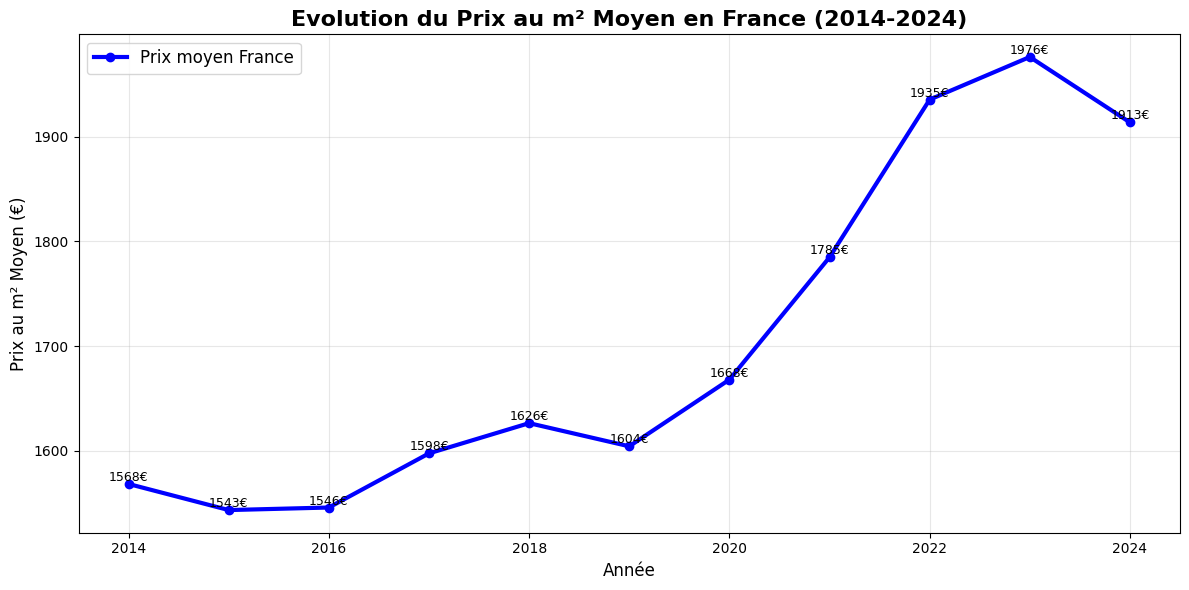


=== STATISTIQUES NATIONALES ===
Prix moyen national (2014-2024) : 1705.77 €/m²
Surface moyenne nationale : 101.43 m²
Total mutations (2014-2024) : 8,156,164
Prix minimum : 1543.47 €/m² en 2015
Prix maximum : 1975.92 €/m² en 2023

Fichier moyenne nationale sauvegardé !


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Lire toutes les données du fichier CSV
df = pd.read_csv(r'C:\Users\Clement\OneDrive\Bureau\L3 info\Projet info\dataVilleAnnee\dvf_consolidated_dataset.csv', sep=',')

# Calculer la moyenne nationale par année (tous départements confondus)
moyenne_nationale = df.groupby('Annee').agg({
    'Prixm2Moyen': 'mean',
    'SurfaceMoy': 'mean',
    'Nb_mutations': 'sum'
}).reset_index()

moyenne_nationale.columns = ['Annee', 'PrixM2Moyen_France', 'SurfaceMoy_France', 'Total_Mutations_France']

# Afficher les résultats
print("Moyenne nationale par année :")
print(moyenne_nationale)

# Créer un graphique de l'évolution du prix moyen en France
plt.figure(figsize=(12, 6))

plt.plot(moyenne_nationale['Annee'], moyenne_nationale['PrixM2Moyen_France'], 
         marker='o', linewidth=3, color='blue', label='Prix moyen France')

plt.title('Evolution du Prix au m² Moyen en France (2014-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Année', fontsize=12)
plt.ylabel('Prix au m² Moyen (€)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Ajouter les valeurs sur le graphique
for i, row in moyenne_nationale.iterrows():
    plt.text(row['Annee'], row['PrixM2Moyen_France'], 
             f"{row['PrixM2Moyen_France']:.0f}€", 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(r'C:\Users\Clement\OneDrive\Bureau\L3 info\Projet info\dataVilleAnnee\moyenne_nationale.png', dpi=300)
plt.show()

# Statistiques globales
print(f"\n=== STATISTIQUES NATIONALES ===")
print(f"Prix moyen national (2014-2024) : {moyenne_nationale['PrixM2Moyen_France'].mean():.2f} €/m²")
print(f"Surface moyenne nationale : {moyenne_nationale['SurfaceMoy_France'].mean():.2f} m²")
print(f"Total mutations (2014-2024) : {moyenne_nationale['Total_Mutations_France'].sum():,.0f}")
print(f"Prix minimum : {moyenne_nationale['PrixM2Moyen_France'].min():.2f} €/m² en {moyenne_nationale[moyenne_nationale['PrixM2Moyen_France'] == moyenne_nationale['PrixM2Moyen_France'].min()]['Annee'].values[0]}")
print(f"Prix maximum : {moyenne_nationale['PrixM2Moyen_France'].max():.2f} €/m² en {moyenne_nationale[moyenne_nationale['PrixM2Moyen_France'] == moyenne_nationale['PrixM2Moyen_France'].max()]['Annee'].values[0]}")

# Sauvegarder les résultats
moyenne_nationale.to_csv(r'C:\Users\Clement\OneDrive\Bureau\L3 info\Projet info\dataVilleAnnee\moyenne_nationale.csv', sep=',', index=False)

print("\nFichier moyenne nationale sauvegardé !")